## Genetic Algorithm for discovering best design given stats inputs

We create two fMRI designs by hand and compare their efficiency, then use `neurodesign`'s genetic-algorithm optimizer — which applies crossover and mutation internally across a whole population of designs — to search for a new design that is more statistically optimal than either hand-built one.

---

## Credit

Note: This notebook is an extension of Neurodesign's [examples](https://github.com/neuropower/neurodesign/blob/master/examples/comparison_neurodesign.ipynb).

### 📋 Experimental Setup
We define an experiment with the following parameters:
* Repetition Time (TR): 1.2s — This is the temporal resolution of the fMRI acquisition.
* Number of Trials: 20 — A short toy design for demonstration, later extended.
* Stimulus Conditions: 3 — Each trial presents one of three task conditions.
* Condition Probabilities: [0.3, 0.3, 0.4] — Slightly higher representation of the third condition.
* Contrasts: Two pairwise comparisons: Condition 1 vs 2, and Condition 2 vs 3.
* Stimulus Duration: 1s — Short stimulus presentations.
* Autocorrelation (ρ): 0.3 — Assumes moderate temporal correlation in the fMRI noise.
* ITI Model: Uniform between 2s and 4s — Models a simple jittered baseline period.

These parameters are passed into a neurodesign.Experiment object, which encapsulates the statistical and temporal characteristics of the design.

---

### 🧪 Design 1 and Design 2: Efficiency Comparison
Two specific trial sequences (i.e., orders) are evaluated:

1. Design 1: A rotating sequence [0, 1, 2, ...] with all three conditions repeating in succession. ITIs are fixed at 2s.
2. Design 2: A block design with clusters of the same condition (e.g., 5 trials of condition 0, then 5 of condition 1, etc.).

We compute the following for each design:
* The convolved design matrix, representing how the experimental manipulation maps onto BOLD responses over time.
* The detection efficiency (Fd) and estimation efficiency (Fe) — two standard metrics from statistical design theory:
* Fd assesses how well the design detects condition differences.
* Fe assesses how well it estimates the shape of the hemodynamic response.

---

### 🔁 Building Blocks for Optimization
Before running full automatic optimization, we generate the raw ingredients it samples from: random trial orders and jittered inter-trial intervals. Internally, `neurodesign`'s genetic-algorithm optimizer applies crossover and mutation to a whole population of such designs across many generations — this is not a single one-off crossover between Design 1 and Design 2.

Here we generate:
* A random order of 100 trials across 4 conditions, drawn with unequal probabilities [0.5, 0.25, 0, 0.25] — condition 0 is oversampled and condition 2 never occurs, illustrating how skewed `probabilities` shape the resulting order.
* A set of exponentially distributed ITIs (mean = 3s, bounded between 2s–8s) to create jitter for de-correlating neural events in the GLM.

This illustrates how to simulate more realistic, variable-timing designs, which increase design efficiency.

---

### 🧬 Full Design Optimization
Finally, we use neurodesign.Optimisation to simulate evolutionary design optimization. The genetic algorithm iteratively selects, crosses over, and mutates trial sequences to improve a weighted sum of efficiency metrics. Weights are always given in the order `[Fe, Fd, Ff, Fc]`:
* weights=[0, 0.5, 0.25, 0.25] emphasizes:
* 0.0: Estimation efficiency (Fe) — not optimized in this run
* 0.5: Detection power (Fd)
* 0.25: Frequency balance (Ff)
* 0.25: Confound reduction (Fc)

The optimizer runs for a small number of cycles here (preruncycles=2, cycles=6) to keep this tutorial fast; increase both for a production-quality search. It gradually converges toward a design that is statistically superior in terms of detecting BOLD responses for the specified contrasts.

---

## Initial Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neurodesign

In [2]:
import os
# Since Neurodesign uses multi-threading internally, limit the number of threads
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

## Define experiment setup

In [3]:
from collections import Counter
from pathlib import Path
from rich import print

# ------------------------
# DEFINE EXPERIMENT SETUP
# ------------------------

# Create an Experiment object defining general fMRI design parameters
exp = neurodesign.Experiment(
    TR=1.2,               # Repetition Time (TR) in seconds
    n_trials=20,          # Total number of trials
    P=[0.3, 0.3, 0.4],    # Probabilities for each of the 3 conditions
    C=[[1, -1, 0],        # Contrasts of interest (e.g., cond1 vs cond2)
       [0, 1, -1]],       # and cond2 vs cond3
    n_stimuli=3,          # Number of stimulus/conditions
    rho=0.3,              # Autocorrelation of the noise in fMRI signal
    event_durations=1,      # Duration of each stimulus/event
    inter_trial_interval={
        "model": "uniform",
        "min": 2,
        "max": 4              # Maximum ITI,
    },)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.09999999999999999
  warnings.warn(


We first define two experimental designs: alterntting conditions (Design 1) vs block conditions (Design 2)

## Create and evaluate designs

Text(0, 0.5, 'Predicted BOLD (a.u.)')

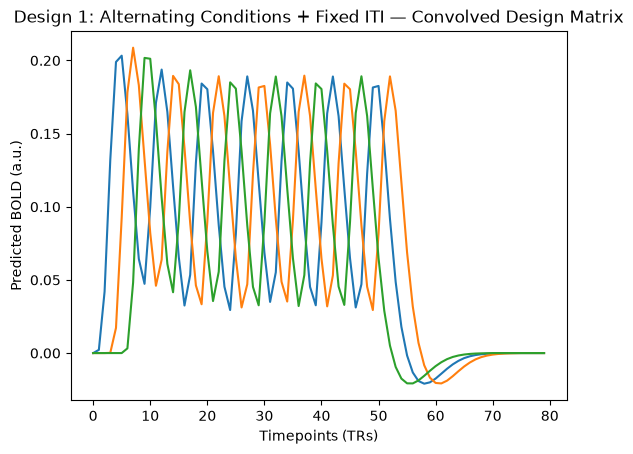

In [4]:
# ------------------------
# CREATE AND EVALUATE DESIGNS
# ------------------------

# Design 1: alternating conditions with fixed ITIs
design_1 = exp.create_manual_design(
    order=[0, 1, 2] * 6 + [0, 1],  # Trial condition sequence (20 trials)
    inter_trial_intervals=[2] * 20,                 # Constant ITI of 2s for each trial
)
design_1.designmatrix()           # Generate design matrix and convolve with HRF
design_1.FCalc(weights=[0.25, 0.25, 0.25, 0.25])  # order: Fe, Fd, Ff, Fc (equal weights here)

plt.plot(design_1.Xconv)         # Plot the convolved design matrix (with HRF)
plt.title("Design 1: Alternating Conditions + Fixed ITI — Convolved Design Matrix")
plt.xlabel("Timepoints (TRs)")
plt.ylabel("Predicted BOLD (a.u.)")

Text(0, 0.5, 'Predicted BOLD (a.u.)')

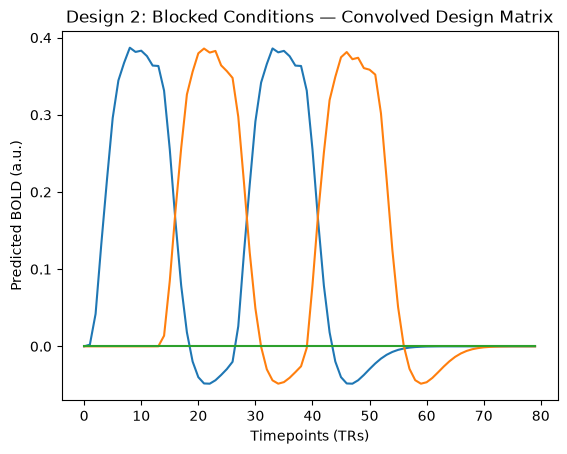

In [5]:
# ------------------------
# CREATE AND EVALUATE DESIGNS
# ------------------------

# Design 2: blocked condition structure
design_2 = exp.create_manual_design(
    order=[0]*5 + [1]*5 + [0]*5 + [1]*5,  # Blocked sequence of conditions
    inter_trial_intervals=[2] * 20,                        # Constant ITI
)
design_2.designmatrix()             # Generate design matrix and convolve with HRF
design_2.FCalc(weights=[0.25, 0.25, 0.25, 0.25])  # order: Fe, Fd, Ff, Fc (equal weights here)

plt.plot(design_2.Xconv)         # Plot the convolved design matrix (with HRF)
plt.title("Design 2: Blocked Conditions — Convolved Design Matrix")
plt.xlabel("Timepoints (TRs)")
plt.ylabel("Predicted BOLD (a.u.)")

In [6]:
# Print optimality metrics (from FCalc): Fd = detection, Fe = estimation
print(f"Fe of design 1: {str(design_1.Fe)}")
print(f"Fe of design 2: {str(design_2.Fe)}")
print(f"Fd of design 1: {str(design_1.Fd)}")
print(f"Fd of design 2: {str(design_2.Fd)}")

Fe of design 1: 0.0001436776501624

Fe of design 2: 6.139620163885587e-05

Fd of design 1: 0.08824406392424525

Fd of design 2: 0.42826876480573145

1. Fe – Estimation Efficiency: This measures how well the design allows for precise estimation of the shape and amplitude of the HRF (hemodynamic response) for each condition.

A higher Fe indicates less correlated regressors, and thus better parameter estimation. Design 1's regular alternation gives it the edge here.

2. Fd – Detection Power: This metric reflects the ability to detect condition differences (i.e., statistical power for contrasts).

A higher Fd means greater detection sensitivity for condition effects. Design 2's blocked structure gives it the edge here.

Next, we run the genetic algorithm to search for a design that jointly optimizes Fd, Ff, and Fc (with Fd weighted most heavily — see the weights below).

## Generate random order

In [7]:
# ------------------------
# GENERATE RANDOM ORDER
# ------------------------

# Generate a random stimulus order for 4 conditions and 100 trials
order = neurodesign.generate.order(
    nstim=4,
    ntrials=100,
    probabilities=[0.5, 0.25, 0, 0.25],
    ordertype="random",
    seed=1234
)
print(order[:10])          # Print first 10 items of generated order
Counter(order)             # Count occurrences of each condition

[0, 1, 3, 3, 1, 3, 0, 0, 0, 0]

Counter({0: 46, 1: 29, 3: 25})

## Generate jittered ITI

In [8]:
# ------------------------
# GENERATE JITTERED ITI
# ------------------------

# Generate exponential ITIs with bounds
iti, lam = neurodesign.generate.iti( # lam : lambda, parameter for exponential
    ntrials=40,
    model="exponential",
    min=2,
    mean=3,
    max=8,
    resolution=0.1,
    seed=2134
)

print(iti[:10])            # Show the first 10 ITIs
print(
    f"mean ITI: {round(sum(iti) / len(iti), 2)}\n"
    f"min ITI: {round(min(iti), 2)}\n"
    f"max ITI: {round(max(iti), 2)}\n"
)

[0.  3.2 2.  2.2 2.5 2.1 2.1 3.9 3.  5.5]

mean ITI: 2.92
min ITI: 0.0
max ITI: 5.5

## Run genetic optimization

In [9]:
# ------------------------
# RUN GENETIC OPTIMIZATION
# ------------------------

# Optimize designs using genetic algorithm
population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0], # 100% blocked, 0% random, 0% msequence
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc -> emphasize Fd (detection)
    preruncycles=2,                # Warm-up iterations for a tutorial-scale run
    cycles=6,                     # Main genetic algorithm iterations for a tutorial-scale run
    folder="./",                   # Output folder for results
    seed=100                       # Seed for reproducibility
)

population.optimise()             # Run the optimization

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

We can now observe the best design. First let's take a look at the metrics:

## Inspect best design

In [10]:
best_design = population.selected_design(0)  # The best subject from the final generation

print(f"Fe (estimation efficiency): {best_design.Fe}")
print(f"Fd (detection efficiency): {best_design.Fd}")
print(f"Fc (confounding): {best_design.Fc}")
print(f"Ff (stimulus frequency balance): {best_design.Ff}")


Fe (estimation efficiency): 0.0

Fd (detection efficiency): 1.1053356844957931

Fc (confounding): 0.6344879803142155

Ff (stimulus frequency balance): 0.8571428571428572

We can see that the new design outperforms Design 1 and Design 2 on the Fd metric.
However, estimation efficiency was not computed here (its weight was 0), and confounding is moderate: `Fc` is normalized so that 1.0 is ideal (perfectly balanced condition transitions) and 0.0 is worst, so the observed reflects decent, but not perfect, balance between the different conditions' timecourses. Ideally, we would want `Fc` as close to 1 as possible.

We obtain a design matrix with 67 timepoints/TRs (duration in TR) and 3 regressors, 1 per condition.  
We can have a look at the design matrix below.

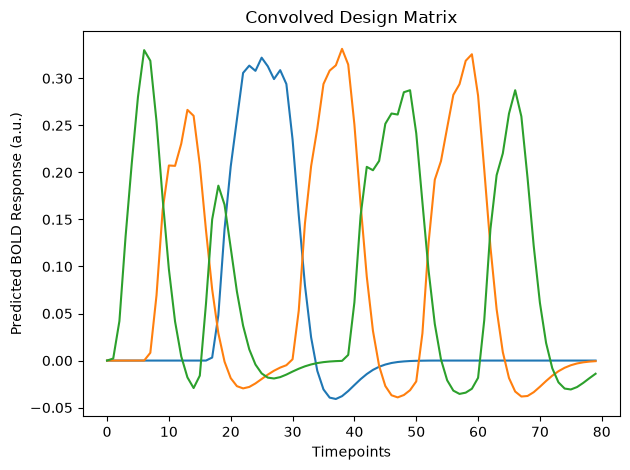

In [11]:
plt.plot(best_design.Xconv)
plt.title("Convolved Design Matrix")
plt.xlabel("Timepoints")
plt.ylabel("Predicted BOLD Response (a.u.)")
plt.tight_layout()
plt.show()

In [12]:
print("Shape of Xconv:", best_design.Xconv.shape)

Shape of Xconv:
(80, 3)

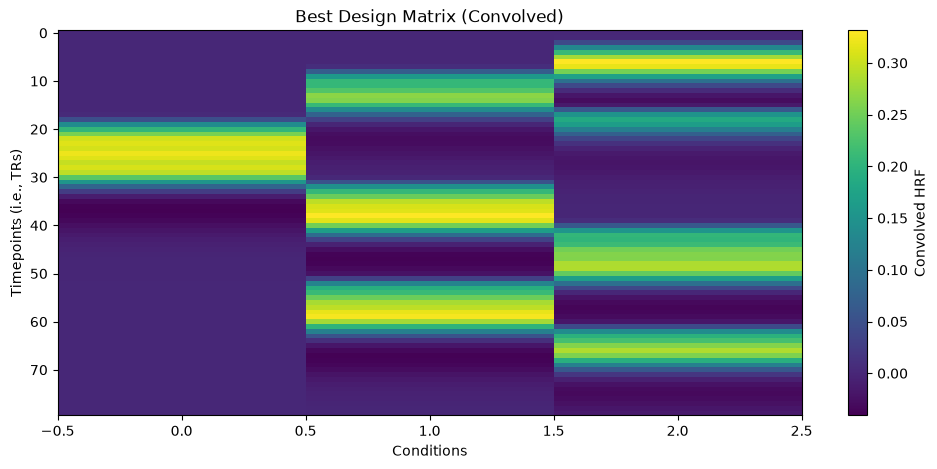

In [13]:
best_design.designmatrix()
plt.figure(figsize=(12, 5))
plt.imshow(best_design.Xconv, aspect='auto', cmap='viridis')
plt.colorbar(label='Convolved HRF')
plt.title("Best Design Matrix (Convolved)")
plt.xlabel("Conditions")
plt.ylabel("Timepoints (i.e., TRs)")
plt.show()

We can have a look at the distribution of ITI below:

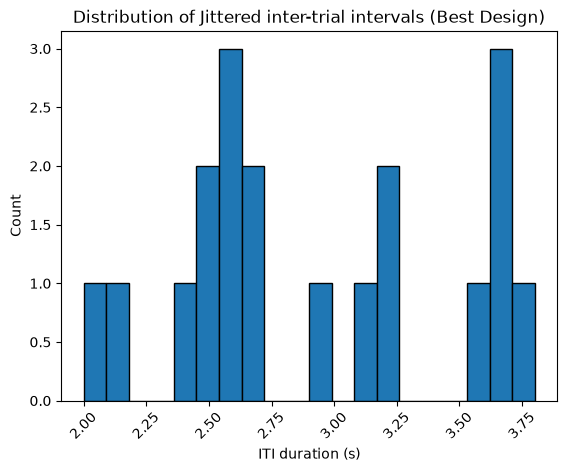

In [14]:
plt.hist(best_design.realized_inter_trial_intervals, bins=20, edgecolor='black')
plt.title("Distribution of Jittered inter-trial intervals (Best Design)")
plt.xlabel("ITI duration (s)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

And we can ask get the stimuli order and corresponding ITI of the best design, as below:

In [15]:
print("Stimulus order:", best_design.order)
print("Inter-trial interval sequence:", best_design.realized_inter_trial_intervals)

Stimulus order:
[2, 2, 1, 1, 2, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2]

Inter-trial interval sequence: [2.1 2.7 3.6 3.7 2.  2.6 2.6 2.6 3.7 2.7 2.5 2.5 3.8 2.9 3.7 3.2 2.4 3.2
 3.1]